# 🧠 Deep Learning Practical Assignment (Adult Income Dataset)

## 📌 Dataset
We will use the **Adult Income dataset** (also known as the Census Income dataset).  
The task is to predict whether a person earns **more than $50K/year** based on demographic and employment attributes.

---


In [5]:
# Option 1: Using OpenML via scikit-learn
from sklearn.datasets import fetch_openml
import pandas as pd
# Load dataset from OpenML
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame


In [6]:
df.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,NaN,227026,HS-grad,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


## Part 0: Data Preparation
1. Load the dataset into a DataFrame.
2. Split the data into **training, validation, and test sets**.  
   - Suggested: 70% training, 15% validation, 15% test.
3. Apply any necessary preprocessing:
   - Handle categorical features (encoding).
   - Scale numerical features if needed.
4. After training your models, always report results on:
   - **Training accuracy**
   - **Validation accuracy**
   - **Test accuracy**
5. At the end of the assignment, **compare all methods** across train, validation, and test sets.


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

X = df.drop('class', axis=1)
y = df['class']
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 34189 | Val: 7326 | Test: 7327


In [8]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['category', 'object']).columns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) ])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_val_preprocessed = preprocessor.transform(X_val)
X_test_preprocessed = preprocessor.transform(X_test)

y_train = (y_train.str.strip() == '>50K').astype(int)
y_val = (y_val.str.strip() == '>50K').astype(int)
y_test = (y_test.str.strip() == '>50K').astype(int)

print(f"New shape: {X_train_preprocessed.shape}")

New shape: (34189, 105)



## Part 1: Optimizers
1. Train the same neural network using:
   - Stochastic Gradient Descent (SGD)
   - SGD with Momentum
   - Adam
2. Compare the training and validation accuracy for each optimizer.
3. Which optimizer converges the fastest? Which gives the best generalization?
4. Explain *why* Adam often performs better than plain SGD.



In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_model(input_shape):
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_shape,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid') # Binary classification
    ])
    return model

# Dictionary to store results
results = {}
optimizers = {
    'SGD': tf.keras.optimizers.SGD(learning_rate=0.01),
    'SGD_Momentum': tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'Adam': tf.keras.optimizers.Adam(learning_rate=0.001)
}

# Loop through each optimizer
for name, opt in optimizers.items():
    model = build_model(X_train_preprocessed.shape[1])
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

    print(f"Training with {name}...")
    history = model.fit(X_train_preprocessed, y_train,
                        validation_data=(X_val_preprocessed, y_val),
                        epochs=20, batch_size=32, verbose=0)
    results[name] = history

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with SGD...
Training with SGD_Momentum...
Training with Adam...


## Part 2: Batch Size
1. Train the same model with different batch sizes (e.g., 1, 32, 128, 1024).
2. Compare:
   - Training speed
   - Validation accuracy
   - Test accuracy
   - Generalization ability
3. Which batch size leads to the **noisiest gradient updates**?
4. Which batch size generalizes better and why?

In [10]:
import time
import matplotlib.pyplot as plt

batch_sizes = [1, 32, 128, 1024]
batch_results = {}
for b_size in batch_sizes:
    model = build_model(X_train_preprocessed.shape[1])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    start_time = time.time()
    # Training
    history = model.fit(X_train_preprocessed, y_train,
                        validation_data=(X_val_preprocessed, y_val),
                        epochs=5, batch_size=b_size, verbose=0)
    end_time = time.time()
    # Store metrics and total training time
    batch_results[b_size] = {
        'history': history,
        'time': end_time - start_time,
        'test_acc': model.evaluate(X_test_preprocessed, y_test, verbose=0)[1]}
    print(f"Batch Size {b_size} finished in {batch_results[b_size]['time']:.2f} seconds.")

Batch Size 1 finished in 501.18 seconds.
Batch Size 32 finished in 16.39 seconds.
Batch Size 128 finished in 6.95 seconds.
Batch Size 1024 finished in 4.02 seconds.



## Part 3: Overfitting and Regularization
1. Train a large neural network (many parameters) on the dataset.
2. Observe training vs. validation accuracy.  
   - Do you see signs of overfitting?
3. Apply regularization techniques:
   - **L2 regularization**
   - **Dropout**
4. Compare the validation results before and after regularization.
5. Which regularization method was more effective in reducing overfitting? Why?

---


In [11]:
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, regularizers


input_dim = X_train_preprocessed.shape[1]
epochs = 30
batch_size = 128
model_org = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(input_dim,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(1, activation='sigmoid')])

model_org.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
hist_org = model_org.fit(X_train_preprocessed, y_train, validation_data=(X_val_preprocessed, y_val),
                         epochs=epochs, batch_size=batch_size, verbose=0)


model_l2 = models.Sequential([
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=(input_dim,)),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(1, activation='sigmoid')])
model_l2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
hist_l2 = model_l2.fit(X_train_preprocessed, y_train, validation_data=(X_val_preprocessed, y_val),
                        epochs=epochs, batch_size=batch_size, verbose=0)

model_dropout = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(input_dim,)),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')])
model_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
hist_dropout = model_dropout.fit(X_train_preprocessed, y_train, validation_data=(X_val_preprocessed, y_val),
                                 epochs=epochs, batch_size=batch_size, verbose=0)

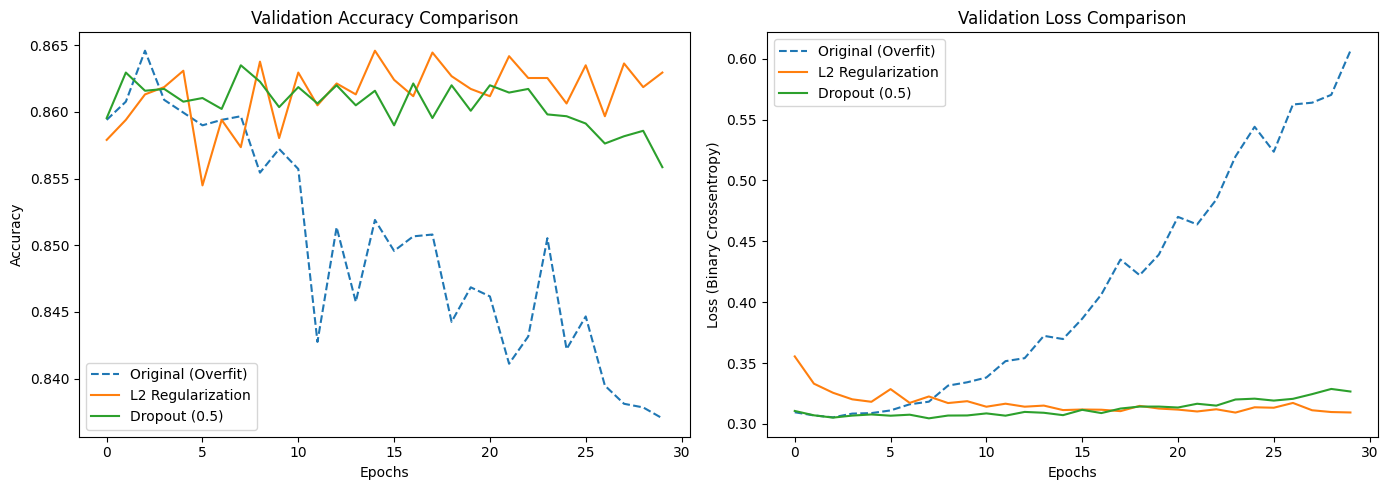

In [12]:
plt.figure(figsize=(14, 5))

# Plot Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(hist_org.history['val_accuracy'], label='Original (Overfit)', linestyle='--')
plt.plot(hist_l2.history['val_accuracy'], label='L2 Regularization')
plt.plot(hist_dropout.history['val_accuracy'], label='Dropout (0.5)')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Validation Loss
plt.subplot(1, 2, 2)
plt.plot(hist_org.history['val_loss'], label='Original (Overfit)', linestyle='--')
plt.plot(hist_l2.history['val_loss'], label='L2 Regularization')
plt.plot(hist_dropout.history['val_loss'], label='Dropout (0.5)')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()

plt.tight_layout()
plt.show()

## Part 4: Early Stopping
1. Train the model for many epochs without early stopping.  
   - Plot training, validation, and test curves.
2. Train again with **early stopping** (monitor validation loss).
3. Compare the number of epochs trained and the final validation/test accuracy.
4. Explain how early stopping helps prevent overfitting.

---

Training baseline (100 epochs)...


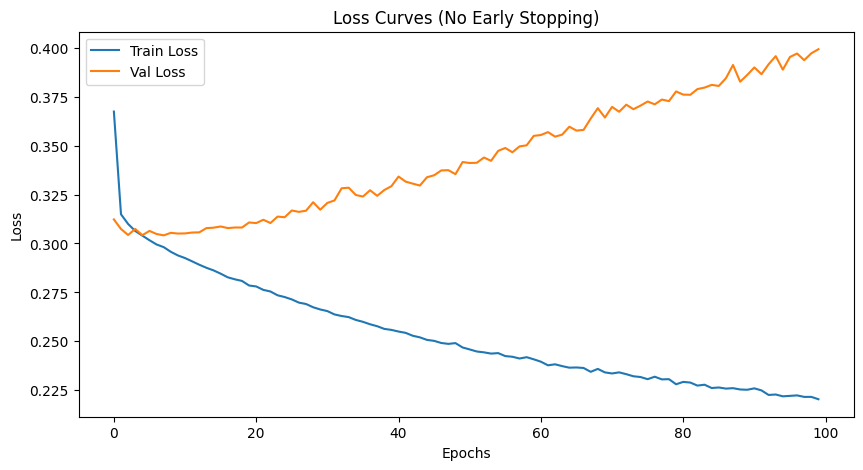

In [13]:
model_baseline = build_model(X_train_preprocessed.shape[1])
model_baseline.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training baseline (100 epochs)...")
history_baseline = model_baseline.fit(
    X_train_preprocessed, y_train,
    validation_data=(X_val_preprocessed, y_val),
    epochs=100, batch_size=128, verbose=0
)

plt.figure(figsize=(10, 5))
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Val Loss')
plt.title('Loss Curves (No Early Stopping)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

# Define the callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True  # Important: goes back to the best version of the model
)

model_es = build_model(X_train_preprocessed.shape[1])
model_es.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training with Early Stopping...")
history_es = model_es.fit(
    X_train_preprocessed, y_train,
    validation_data=(X_val_preprocessed, y_val),
    epochs=100, batch_size=128,
    callbacks=[early_stop],
    verbose=1 # Let's see it stop!
)

epochs_trained = len(history_es.history['loss'])
print(f"Early Stopping stopped training at epoch {epochs_trained}")

Training with Early Stopping...
Epoch 1/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7806 - loss: 0.4415 - val_accuracy: 0.8586 - val_loss: 0.3096
Epoch 2/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8535 - loss: 0.3156 - val_accuracy: 0.8584 - val_loss: 0.3081
Epoch 3/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8572 - loss: 0.3040 - val_accuracy: 0.8609 - val_loss: 0.3045
Epoch 4/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8554 - loss: 0.3091 - val_accuracy: 0.8613 - val_loss: 0.3055
Epoch 5/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8573 - loss: 0.3042 - val_accuracy: 0.8610 - val_loss: 0.3051
Epoch 6/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8603 - loss: 0.3015 - val_accuracy: 0.8567 - val_loss: 0.3093
Epoch 7/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8574 - loss: 0.3055 - val_accuracy: 0.8616 - val_loss: 0.3050
Epoch 8/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 

## Part 5: Reflection
1. Summarize what you learned about:
   - The role of optimizers
   - The effect of batch size
   - Regularization methods
   - Early stopping
   - Train/validation/test splits
2. If you had to train a deep learning model on a new tabular dataset, what choices would you make for:
   - Optimizer
   - Batch size
   - Regularization
   - Early stopping
   - Data splitting strategy  
   and why?

### Optimizer
- The Optimizer is the mathematical algorithm responsible for updating the model's weights to minimize the loss function. While Stochastic Gradient Descent (SGD) applies a uniform learning rate to all parameters, the Adam (Adaptive Moment Estimation) optimizer calculates individual learning rates for each weight. By tracking both the moving average of the gradient and its variance, Adam compensates for features with different scales and frequencies, leading to faster and more stable convergence on tabular data.

### Batch size
- Batch Size determines the number of training samples processed before the model’s internal parameters are updated. Using a Medium Batch Size (typically 32 to 128) provides a balance between the computational efficiency of large batches and the stochastic variance of small batches. This variance is technically beneficial; it introduces a degree of noise into the gradient estimate that helps the model bypass sharp local minima, instead settling into broader, more stable regions of the loss landscape that generalize better to unseen data.

###Regularization and Convergence Control
- Regularization refers to techniques designed to reduce the generalization error of a model without significantly affecting its training error. Dropout is a stochastic regularization method where a predefined percentage of neurons are randomly ignored during each forward and backward pass. This prevents "co-adaptation," where neurons become overly dependent on specific input patterns. By forcing the network to learn redundant representations of the data, the model becomes less sensitive to noise and outliers within the training set.

### Early stopping
- Early Stopping is a form of regularization used to determine the optimal duration of the training phase. It involves monitoring the loss on a separate validation set during each epoch. If the validation loss ceases to decrease and begins to trend upward, it indicates that the model has reached its peak generalization and is starting to overfit the training data. Terminating the process at this inflection point ensures that the model parameters remain at their most effective state for predictive tasks.

### Data Partitioning and Validation Integrity
- The structural integrity of the model's evaluation depends on a rigorous Data Splitting strategy. The dataset is divided into three distinct subsets: Training (used to adjust weights), Validation (used to tune hyperparameters and monitor for overfitting), and Test (used as a final, unbiased assessment). This separation ensures that the performance metrics reported on the test set are a true reflection of the model’s ability to categorize new, unseen data points accurately.